In [1]:
import pandas as pd

In [3]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\Classes\Machine Learning\Abhishek\Text preprocessing\Restaurant_Reviews.tsv",sep="\t")

In [5]:
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [6]:
df.shape

(1000, 2)

In [7]:
import nltk

## Stopwords

In [8]:
from nltk.corpus import stopwords

In [ ]:
import nltk
nltk.download("stopwords")

In [14]:
sw = stopwords.words("english")

In [15]:
len(sw)

198

In [18]:
df["Review"][0]

'Wow... Loved this place.'

In [19]:
"this" in sw

True

In [20]:
"Loved" in sw

False

In [21]:
for i in df["Review"][0].split():
    if i not in sw:
        print(i)

Wow...
Loved
place.


In [24]:
" ".join([i for i in df["Review"][10].split() if i not in sw])

'Service prompt.'

In [25]:
df["Review"][10]

'Service was very prompt.'

In [26]:
"not" in sw

True

In [27]:
" ".join([i for i in "Food was not good".split() if i not in sw])

'Food good'

In [28]:
sw.remove("not")

In [29]:
len(sw)

197

In [ ]:
["not","couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 
'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', 
"needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won',
 "won't", 'wouldn', "wouldn't"]

## Stemming
- remove the suffix to replace with thier root word

In [30]:
from nltk.stem import LancasterStemmer, PorterStemmer

In [31]:
ps = PorterStemmer()

In [32]:
ps.stem("running")

'run'

In [33]:
ps.stem("runs")

'run'

In [34]:
ps.stem("Organised")

'organis'

In [35]:
ls = LancasterStemmer()
ls.stem("running")

'run'

In [36]:
ls.stem("Organised")

'org'

In [37]:
df["Review"][15]

'I was shocked because no signs indicate cash only.'

In [39]:
" ".join([ps.stem(i) for i in df["Review"][15].split()])

'i wa shock becaus no sign indic cash only.'

### Lemmatization
- It is used for converting each word into their dictionary word

In [40]:
from nltk.stem import WordNetLemmatizer

In [41]:
lemma = WordNetLemmatizer()

In [48]:
lemma.lemmatize("Organised",pos='v')

'Organised'

In [54]:
lemma.lemmatize("swiming",pos="v")

'swim'

In [52]:
ps.stem("swiming")

'swime'

In [55]:
" ".join([lemma.lemmatize(i) for i in df["Review"][15].split()])

'I wa shocked because no sign indicate cash only.'

### POS Tagging

In [56]:
from nltk.tag import pos_tag

In [ ]:
nltk.download("wordnet")


In [60]:
pos_tag(df["Review"][15].split())

[('I', 'PRP'),
 ('was', 'VBD'),
 ('shocked', 'VBN'),
 ('because', 'IN'),
 ('no', 'DT'),
 ('signs', 'NNS'),
 ('indicate', 'VBP'),
 ('cash', 'NN'),
 ('only.', 'NN')]

In [ ]:
## create a function to clean the data
# 1. lower
# 2. remove punctiations
# 3. tokenization
# 4. removew stopwords
# 5. apply stemming or lemmatizer

In [98]:
def clean_text(review, technique = None):
    # step-1 lower
    review = review.lower()
    # step-2 remove punctuations
    review = re.sub(r"[^a-zA-Z\s]","",review)
    # step-3 remove stopwords
    review = " ".join([i for i in review.split() if i not in sw])
    #step-4 Tokenization
    review = review.split()
    
    # step-5 Lemmatization
    review = " ".join([lemma.lemmatize(i) for i in review])
    
    return review

In [100]:
import re
df["Cleaned_review"] = df["Review"].apply(clean_text)

In [101]:
df.head()

,Review,Liked,Cleaned_review
0,Wow... Loved this place.,1,wow loved place
1,Crust is not good.,0,crust not good
2,Not tasty and the texture was just nasty.,0,not tasty texture nasty
3,Stopped by during the late May bank holiday of...,1,stopped late may bank holiday rick steve recom...
4,The selection on the menu was great and so wer...,1,selection menu great price


## CountVectorizer / Bag of Words

In [102]:
import sklearn

In [103]:
from sklearn.feature_extraction.text import CountVectorizer

In [107]:
cv = CountVectorizer()
data = cv.fit_transform(df["Cleaned_review"]).toarray()
data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1000, 1810))

In [108]:
data.shape

(1000, 1810)

In [119]:
cv.get_feature_names_out()

array(['absolute', 'absolutely', 'absolutley', ..., 'yum', 'yummy',
       'zero'], shape=(1810,), dtype=object)

In [120]:
len(cv.get_feature_names_out())

1810

In [121]:
pd.DataFrame(data,columns=cv.get_feature_names_out())

,absolute,absolutely,absolutley,accident,accommodation,accomodate,accordingly,accountant,ache,acknowledged,...,yelpers,yet,youd,youll,youre,yucky,yukon,yum,yummy,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [122]:
words = " ".join(df["Cleaned_review"])

In [130]:
len(set(words.split()))

1813

### Find the most occuring words

In [178]:
paragrapgh = " ".join(df["Cleaned_review"])

In [179]:
words_col = pd.Series(paragrapgh.split())

In [180]:
words_col.unique()

array(['wow', 'loved', 'place', ..., 'poured', 'wound', 'drawing'],
      shape=(1813,), dtype=object)

In [183]:
words_col.value_counts()[:10]

food       125
not        116
place      111
good        95
service     84
great       70
back        61
time        55
like        47
go          43
Name: count, dtype: int64

In [184]:
import matplotlib.pyplot as plt

<Axes: >

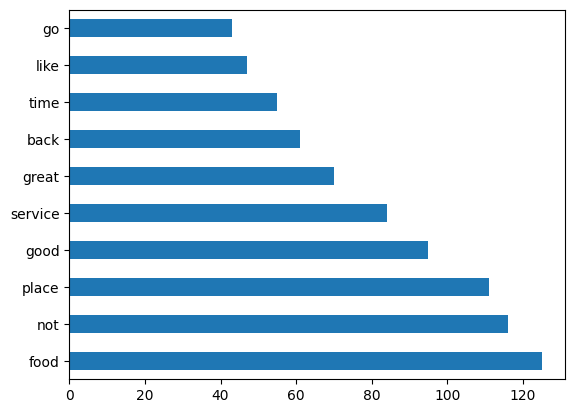

In [186]:
words_col.value_counts()[:10].plot(kind="barh")

In [ ]:
!pip install wordcloud

In [188]:
from wordcloud import WordCloud

In [189]:
wc = WordCloud()

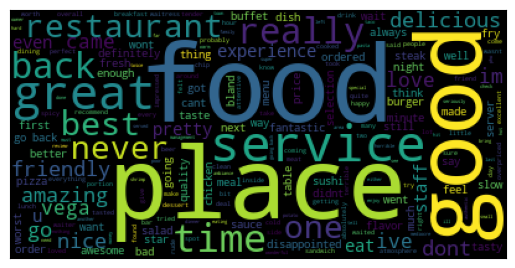

In [193]:
img = wc.generate(paragrapgh)
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.show()

In [194]:
df.columns

Index(['Review', 'Liked', 'Cleaned_review'], dtype='object')

In [195]:
df["Liked"].value_counts()

Liked
1    500
0    500
Name: count, dtype: int64

In [200]:
positive = " ".join(df[df["Liked"]==1]["Cleaned_review"])

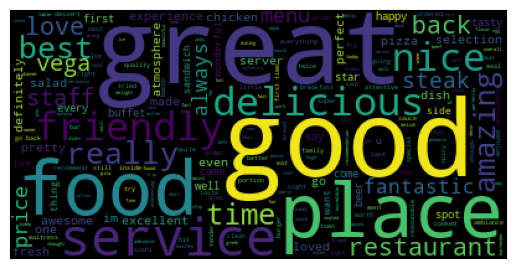

In [201]:
pos = wc.generate(positive)
plt.imshow(pos)
plt.xticks([])
plt.yticks([])
plt.show()

In [202]:
negative = " ".join(df[df["Liked"]==0]["Cleaned_review"])

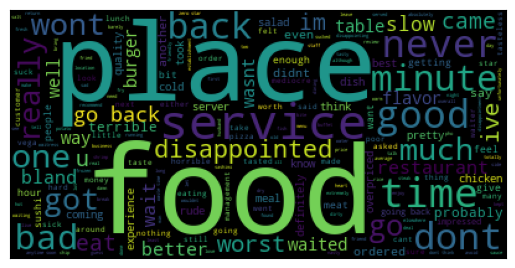

In [203]:
pos = wc.generate(negative)
plt.imshow(pos)
plt.xticks([])
plt.yticks([])
plt.show()

In [204]:
from sklearn.feature_extraction.text import CountVectorizer

In [205]:
cv = CountVectorizer()

In [208]:
data = cv.fit_transform(df["Cleaned_review"])
data

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5606 stored elements and shape (1000, 1810)>

In [209]:
data.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1000, 1810))

In [210]:
dir(cv)

['_CountVectorizer__metadata_request__fit',
 '_CountVectorizer__metadata_request__transform',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_char_ngrams',
 '_char_wb_ngrams',
 '_check_stop_words_consistency',
 '_check_vocabulary',
 '_count_vocab',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_class_level_metadata_request_values',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_limit_features',
 '_parameter_constraints',
 '_repr_html

In [214]:
uniq_words= cv.get_feature_names_out()
uniq_words

array(['absolute', 'absolutely', 'absolutley', ..., 'yum', 'yummy',
       'zero'], shape=(1810,), dtype=object)

In [216]:
cv.vocabulary_["zero"]

1809

In [219]:
cv.vocabulary_["place"]

1174

In [211]:
cv.vocabulary_

{'wow': 1788,
 'loved': 920,
 'place': 1174,
 'crust': 357,
 'not': 1058,
 'good': 665,
 'tasty': 1573,
 'texture': 1585,
 'nasty': 1033,
 'stopped': 1515,
 'late': 869,
 'may': 959,
 'bank': 103,
 'holiday': 752,
 'rick': 1324,
 'steve': 1507,
 'recommendation': 1283,
 'selection': 1391,
 'menu': 981,
 'great': 678,
 'price': 1214,
 'getting': 647,
 'angry': 36,
 'want': 1725,
 'damn': 367,
 'pho': 1162,
 'honeslty': 755,
 'didnt': 408,
 'taste': 1569,
 'fresh': 620,
 'potato': 1203,
 'like': 895,
 'rubber': 1341,
 'could': 328,
 'tell': 1578,
 'made': 934,
 'ahead': 17,
 'time': 1610,
 'kept': 850,
 'warmer': 1728,
 'fry': 629,
 'touch': 1632,
 'service': 1402,
 'prompt': 1228,
 'would': 1784,
 'go': 658,
 'back': 94,
 'cashier': 234,
 'care': 225,
 'ever': 517,
 'say': 1370,
 'still': 1509,
 'ended': 498,
 'wayyy': 1741,
 'overpriced': 1106,
 'tried': 1644,
 'cape': 221,
 'cod': 283,
 'ravoli': 1267,
 'chicken': 259,
 'cranberrymmmm': 342,
 'disgusted': 431,
 'pretty': 1212,
 'sure'

In [222]:
pd.DataFrame(data.toarray(),columns = cv.get_feature_names_out())

,absolute,absolutely,absolutley,accident,accommodation,accomodate,accordingly,accountant,ache,acknowledged,...,yelpers,yet,youd,youll,youre,yucky,yukon,yum,yummy,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [232]:
doc = ["i love machine learning learning learning", "i love deep learning","i love ai"]

In [233]:
data = cv.fit_transform(doc)
data

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (3, 5)>

In [234]:
data.toarray()

array([[0, 0, 3, 1, 1],
       [0, 1, 1, 1, 0],
       [1, 0, 0, 1, 0]])

In [235]:
pd.DataFrame(data.toarray(),columns=cv.get_feature_names_out())

,ai,deep,learning,love,machine
0,0,0,3,1,1
1,0,1,1,1,0
2,1,0,0,1,0


In [236]:
binary_bow = CountVectorizer(binary=True)

In [238]:
binary_bow.fit_transform(doc).toarray()

array([[0, 0, 1, 1, 1],
       [0, 1, 1, 1, 0],
       [1, 0, 0, 1, 0]])

### CountVectorizer from Scratch

In [239]:
doc

['i love machine learning learning learning',
 'i love deep learning',
 'i love ai']

In [240]:
def clean_text(doc):
    doc = doc.lower()
    doc = re.sub(r"[^a-zA-Z\s]","",doc)
    return doc

In [270]:
def MyBOW(corpus):
    # step-1 cleaning text
    cleaned_sentance = [clean_text(sentance) for sentance in corpus]
    # step-2 finding uniq words
    uniq_words = sorted(list(set(word for sentance in cleaned_sentance for word in sentance.split())))

    bow_matrix=[]
    for sentance in corpus:
        word_count = []
        # each sentacne in the columns
        words = sentance.split()
        #[i,love,machine, learning]
        for i in uniq_words:
            word_count.append(words.count(i))
        bow_matrix.append(word_count)
    df_bow = pd.DataFrame(bow_matrix, columns=uniq_words)
    return df_bow

In [271]:
MyBOW(doc)

,ai,deep,i,learning,love,machine
0,0,0,1,3,1,1
1,0,1,1,1,1,0
2,1,0,1,0,1,0


In [260]:
doc

['i love machine learning learning learning',
 'i love deep learning',
 'i love ai']

In [261]:
import sklearn

In [263]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [264]:
tfidf = TfidfVectorizer()

In [266]:
data = tfidf.fit_transform(doc)

In [267]:
data.toarray()

array([[0.        , 0.        , 0.89118522, 0.23069494, 0.39060049],
       [0.        , 0.72033345, 0.54783215, 0.42544054, 0.        ],
       [0.861037  , 0.        , 0.        , 0.50854232, 0.        ]])

In [269]:
pd.DataFrame(data.toarray(),columns=tfidf.get_feature_names_out())

,ai,deep,learning,love,machine
0,0.000000,0.000000,0.891185,0.230695,0.3906
1,0.000000,0.720333,0.547832,0.425441,0.0000
2,0.861037,0.000000,0.000000,0.508542,0.0000


In [273]:
pwd

'C:\\Users\\DELL\\Desktop\\Classes\\ML_Batch_474_477_482'